In [1]:
import os

import equinox as eqx
import jax
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pop_down_gym.pd_gym_stateless import PopDownGymStateless
from scripts.es.train.es_closed_loop import plot_test_set_trajectories
from scripts.es.train.es_open_loop import CubicTrajectory, rollout_open_loop

/home/cbd/.cache/pypoetry/virtualenvs/pop-down-gym--w4VtYJu-py3.9/lib/python3.9/site-packages/jaxtyping/__init__.py:221: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(


In [2]:
# Hyperparams
num_control_points = 10
num_eval_rollouts = 1000
simulation_steps = 100

# Set the seed for reproducibility
prng_key = jax.random.PRNGKey(0)

# Load the environment
env = PopDownGymStateless.create_env()

2023-12-21 21:36:30.307267: W external/xla/xla/service/gpu/nvptx_compiler.cc:698] The NVIDIA driver's CUDA version is 12.0 which is older than the ptxas CUDA version (12.3.103). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [6]:

# Load the trajectory
prng_key, subkey = jax.random.split(prng_key)
initial_traj = CubicTrajectory(subkey, num_control_points, env.n_actions)
results_dir = (
    "../../../tmp/es/open_loop_dense-cubic-tuned/uncertainty_1.00/lr_1.0e-01"
)
best_trajectory = eqx.tree_deserialise_leaves(
    os.path.join(results_dir, "best_trajectory.eqx"), initial_traj
)

# Simulate a bunch of trajectories
keys = jax.random.split(prng_key, num_eval_rollouts)
rollout_test = lambda key, traj: rollout_open_loop(key, env, traj, simulation_steps)  # noqa
(
    rewards_test,
    states_test,
    t_test,
    reward_inputs_test,
    _,
    hit_goal_test,
    actions_test,
    params_test,
) = jax.vmap(rollout_test, in_axes=(0, None))(keys, best_trajectory)

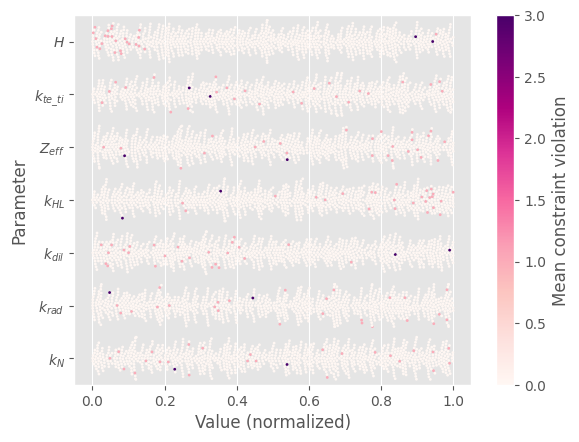

In [29]:
def constraint_violation(reward_inputs, upper_bounds):
    """Compute the maximum constraint violation."""
    total_violation = 0.0
    for key in upper_bounds:
        violation = (reward_inputs[key] >= upper_bounds[key] * 1.05) * env.reward_model.params[
            "hit_barrier_reward"
        ]
        total_violation += violation.mean()

    return total_violation

violation = jax.vmap(constraint_violation, in_axes=(0, None))(
    reward_inputs_test, env.reward_model.limits
)

# Re-map param keys to latex
new_param_keys = {
    "ion_dilution": r"$k_{dil}$",
    "hl_factor": r"$k_{HL}$",
    "Hfactor": r"$H$",
    "Zeff": r"$Z_{eff}$",
    "Te_over_Ti": r"$k_{te\_ti}$",
    "tau_n_factor": r"$k_{N}$",
    "prad_mult": r"$k_{rad}$",
}
params = {new_param_keys[key]: value for key, value in params_test.items()}

# Normalize values by their min/max range
param_ranges = {
    new_param_keys[key]: (lb, ub - lb)
    for key, (lb, ub) in env.random_param_ranges.items()
}
normalized_params = {
    key: (value - param_ranges[key][0]) / param_ranges[key][1]
    for key, value in params.items()
}

# Create a dataframe for each parameter
df = pd.concat(
    [
        pd.DataFrame(
            {
                "Parameter": param,
                "Value (normalized)": value,
                "Mean constraint violation": -violation,
            }
        )
        for param, value in normalized_params.items()
    ]
)

plt.style.use("ggplot")
ax = sns.swarmplot(
    x="Value (normalized)",
    y="Parameter",
    data=df,
    hue="Mean constraint violation",
    legend="brief",
    size=2,
    palette="RdPu",
)
plt.legend([],[], frameon=False)
norm = plt.Normalize(df["Mean constraint violation"].min(), df["Mean constraint violation"].max())
sm = plt.cm.ScalarMappable(cmap="RdPu", norm=norm)
cbar = plt.colorbar(sm, ax = plt.gca())
cbar.set_label("Mean constraint violation")

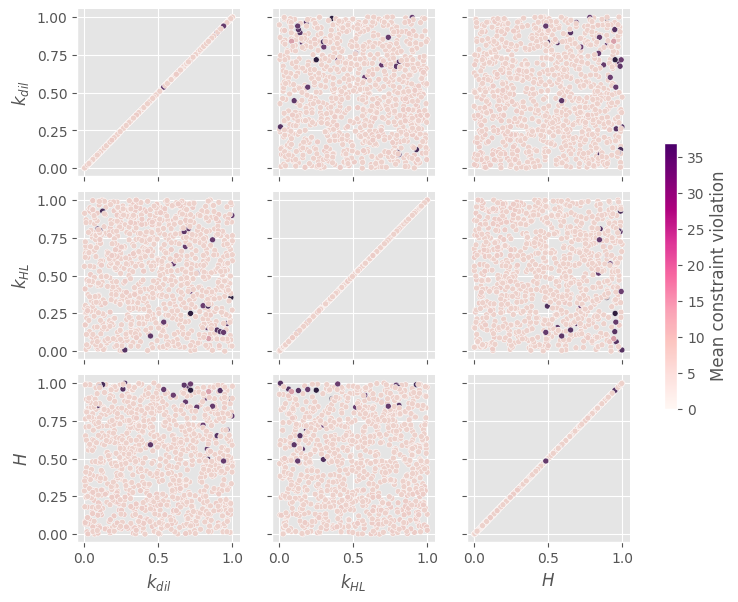

In [25]:
df = pd.DataFrame(
    {key: value for key, value in normalized_params.items()} | {
        "Mean constraint violation": -violation,
    }
)
params_of_interest = [
    r"$k_{dil}$",
    r"$k_{HL}$",
    r"$H$",
    # r"$k_{te\_ti}$",
]
g = sns.PairGrid(df, hue="Mean constraint violation", vars=params_of_interest)
g.map(sns.scatterplot, size=2, palette="RdPu")
norm = plt.Normalize(df["Mean constraint violation"].min(), df["Mean constraint violation"].max())
sm = plt.cm.ScalarMappable(cmap="RdPu", norm=norm)
cbar = plt.colorbar(sm, ax = plt.gcf().get_axes(), shrink=0.5)
cbar.set_label("Mean constraint violation")
plt.gcf().set_size_inches(8, 6)

In [30]:
(violation < 0).sum() / num_eval_rollouts

Array(0.027, dtype=float32)